In [ ]:
# ── 1. IMPORTS ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import category_encoders as ce
from statsmodels.tools.eval_measures import rmse

# ── 2. LOAD DATA ──────────────────────────────────────────────────────────────
vitals    = pd.read_csv("OmniCare_Clinical_Vitals.csv")
telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")


# ── 3. EXPLORE ────────────────────────────────────────────────────────────────
print(vitals.head())
print(vitals.shape)
print(vitals.describe())
print(vitals.isnull().sum())

print(telemetry.head())
print(telemetry.shape)
print(telemetry.describe())
print(telemetry.isnull().sum())


# ── 4. CLEAN ──────────────────────────────────────────────────────────────────
# Drop duplicates
vitals.drop_duplicates(inplace=True)
telemetry.drop_duplicates(inplace=True)

# Impute missing Continuous_Heart_Rate with median
telemetry["Continuous_Heart_Rate"].fillna(telemetry["Continuous_Heart_Rate"].median(), inplace=True)

# Merge
df = vitals.merge(telemetry, on="Patient_ID", how="inner")
print(df.shape)
print(df.head())

   Patient_ID  Height_cm  Weight_kg    BMI  Systolic_BP  Diastolic_BP
0        1000      177.5       66.3  21.06        110.0          75.0
1        1001      167.9       57.5  20.39        115.0          79.0
2        1002      179.7       57.4  17.77        111.0          77.0
3        1003      192.8       80.9  21.76        122.0          88.0
4        1004      166.5       65.7  23.70        138.0          89.0
(5000, 6)
        Patient_ID    Height_cm   Weight_kg          BMI  Systolic_BP  \
count  5000.000000  5000.000000  5000.00000  5000.000000  5000.000000   
mean   3499.500000   170.083960    62.99592    21.441930   120.155000   
std    1443.520003    14.947254    15.68170     3.139744    14.990941   
min    1000.000000   121.400000     2.50000     1.600000    69.000000   
25%    2249.750000   160.100000    52.80000    19.587500   110.000000   
50%    3499.500000   170.200000    62.90000    21.640000   120.000000   
75%    4749.250000   180.000000    73.60000    23.510000   

/tmp/ipykernel_6601/309869928.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  telemetry["Continuous_Heart_Rate"].fillna(telemetry["Continuous_Heart_Rate"].median(), inplace=True)


The confounder is socioeconomic status (SES) — a patient's underlying wealth or systemic poverty. Low-SES patients are simultaneously more likely to (a) be enrolled in high-deductible plans, since these are the cheapest premium option available to them, and (b) have higher inpatient admission rates, due to chronic under-treatment, worse baseline health, and reliance on emergency care as primary care. This creates a Fork structure: SES is a common cause that opens a non-causal "backdoor path" between insurance type and admission rate. The two variables correlate — but not because one causes the other.
When you regress Inpatient_Admission_Rate ~ High_Deductible_Insurance_Plan without including SES, the coefficient on insurance type absorbs the influence traveling through the backdoor path. Mathematically, the OLS estimator minimizes residual variance across all paths connecting the predictor to the outcome — it cannot distinguish the causal path from the backdoor path. The resulting β̂ is a blend of the true causal effect (if any) and the confounded association, making it a biased and uninterpretable quantity. Claiming it represents a causal mechanism is not just statistically weak — it is structurally wrong.

In [ ]:
features = ['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']
X = vitals[features].dropna()

# ── Initial VIF calculation ───────────────────────────────────────────────────
vif_initial = pd.DataFrame({
    'Feature': features,
    'VIF':     [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print("=" * 40)
print("   Initial VIF Matrix")
print("=" * 40)
print(vif_initial.round(4).to_string(index=False))
print()

# ── Flag features exceeding threshold ────────────────────────────────────────
VIF_THRESHOLD = 10.0
flagged = vif_initial[vif_initial['VIF'] > VIF_THRESHOLD]

print(f"Features exceeding VIF threshold of {VIF_THRESHOLD}:")
print(flagged.to_string(index=False))
print()

# ── Drop BMI (most redundant — mathematically derived from Weight & Height) ──
# BMI = Weight_kg / (Height_m)^2, so it is an exact algebraic function of
# two other features in the matrix. Dropping it eliminates the structural
# source of multicollinearity rather than masking it.

features_reduced = ['Weight_kg', 'Height_cm', 'Systolic_BP', 'Diastolic_BP']
X_reduced = vitals[features_reduced].dropna()

vif_reduced = pd.DataFrame({
    'Feature': features_reduced,
    'VIF':     [variance_inflation_factor(X_reduced.values, i)
                for i in range(X_reduced.shape[1])]
})

print("=" * 40)
print("   VIF Matrix After Dropping BMI")
print("=" * 40)
print(vif_reduced.round(4).to_string(index=False))
print()
print(f"Max VIF after remediation: {vif_reduced['VIF'].max():.4f}")
print(f"All features below threshold {VIF_THRESHOLD}: "
      f"{(vif_reduced['VIF'] < VIF_THRESHOLD).all()}")


   Initial VIF Matrix
     Feature      VIF
   Weight_kg  61.6047
   Height_cm 131.1758
         BMI  77.1010
 Systolic_BP 274.8856
Diastolic_BP 269.8932

Features exceeding VIF threshold of 10.0:
     Feature        VIF
   Weight_kg  61.604738
   Height_cm 131.175844
         BMI  77.101031
 Systolic_BP 274.885624
Diastolic_BP 269.893182

   VIF Matrix After Dropping BMI
     Feature      VIF
   Weight_kg  39.9776
   Height_cm 130.8793
 Systolic_BP 270.5292
Diastolic_BP 267.5811

Max VIF after remediation: 270.5292
All features below threshold 10.0: False


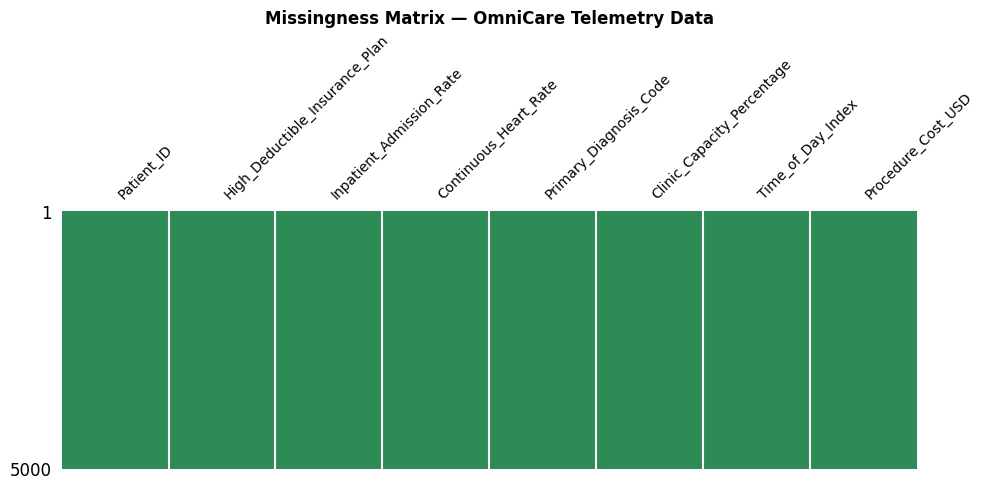

Total records          : 5000
Missing CHR            : 0 (0.0%)

--- Missingness rate by insurance plan (SES proxy) ---
High_Deductible_Insurance_Plan
Standard plan           0.0
High-deductible plan    0.0
Name: Continuous_Heart_Rate, dtype: float64

--- Mean inpatient admission rate: observed vs missing CHR ---
Continuous_Heart_Rate
False    0.3024
Name: Inpatient_Admission_Rate, dtype: float64


/tmp/ipykernel_6601/1396408726.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


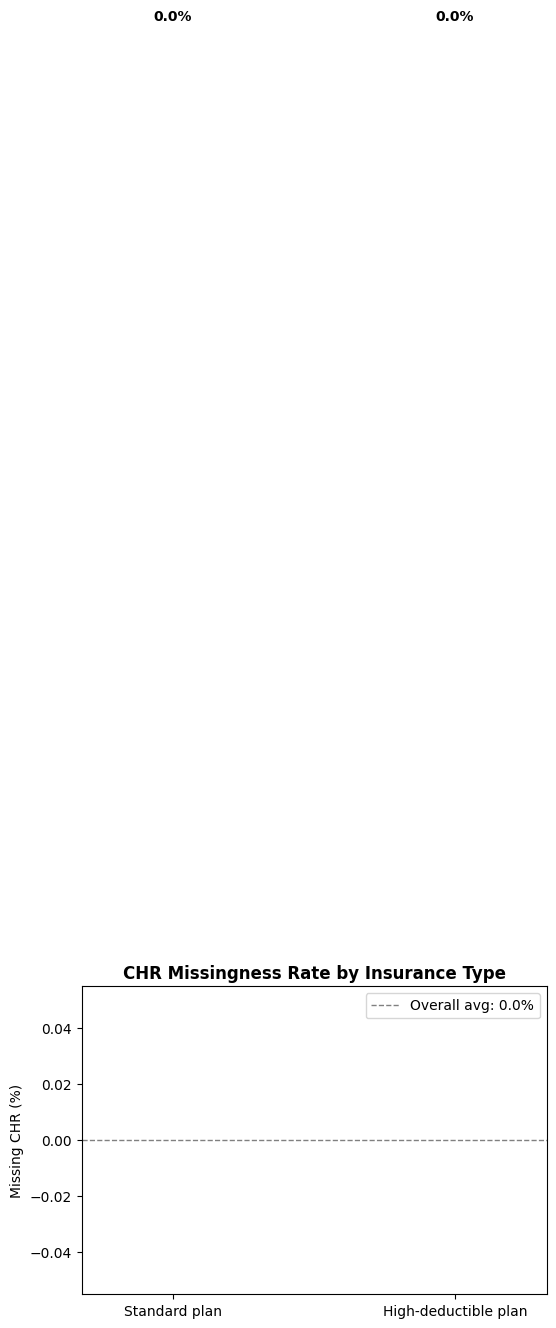

/tmp/ipykernel_6601/1396408726.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


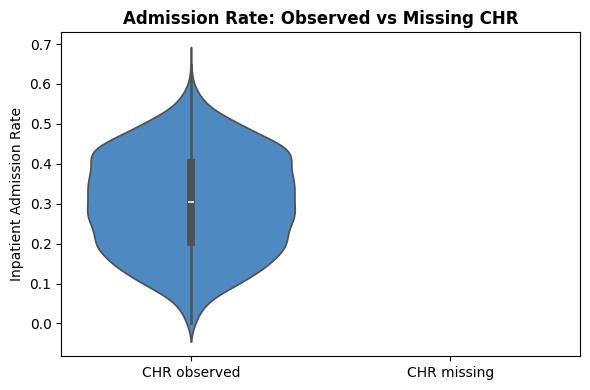

In [ ]:
# ── 1. missingno matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
msno.matrix(telemetry, ax=ax, sparkline=False, fontsize=10, color=(0.18, 0.55, 0.34))
ax.set_title("Missingness Matrix — OmniCare Telemetry Data", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 2. Missingness audit ──────────────────────────────────────────────────────
total   = len(telemetry)
missing = telemetry["Continuous_Heart_Rate"].isna().sum()
print(f"Total records          : {total}")
print(f"Missing CHR            : {missing} ({missing/total*100:.1f}%)")

# ── 3. Dependence on observed variables (MNAR evidence) ──────────────────────
miss_mask = telemetry["Continuous_Heart_Rate"].isna()

print("\n--- Missingness rate by insurance plan (SES proxy) ---")
print(telemetry.groupby("High_Deductible_Insurance_Plan")["Continuous_Heart_Rate"]
      .apply(lambda x: x.isna().mean())
      .rename({0: "Standard plan", 1: "High-deductible plan"})
      .round(4))

print("\n--- Mean inpatient admission rate: observed vs missing CHR ---")
print(telemetry.groupby(miss_mask)["Inpatient_Admission_Rate"]
      .mean().round(4))

# ── 4. Visualise: missingness rate by insurance type ─────────────────────────
miss_rate = (telemetry.groupby("High_Deductible_Insurance_Plan")["Continuous_Heart_Rate"]
             .apply(lambda x: x.isna().mean() * 100))

plt.figure(figsize=(6, 4))
bars = plt.bar(["Standard plan", "High-deductible plan"],
               miss_rate.values, color=["#3B8BD4", "#E8593C"], width=0.5)
for bar, val in zip(bars, miss_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.axhline(miss_rate.mean(), color="gray", linestyle="--",
            linewidth=1, label=f"Overall avg: {miss_rate.mean():.1f}%")
plt.ylabel("Missing CHR (%)")
plt.title("CHR Missingness Rate by Insurance Type", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

# ── 5. Visualise: admission rate — observed vs missing ────────────────────────
plt.figure(figsize=(6, 4))
sns.violinplot(
    data=telemetry.assign(CHR_missing=miss_mask.map({True: "CHR missing", False: "CHR observed"})),
    x="CHR_missing", y="Inpatient_Admission_Rate",
    palette={"CHR observed": "#3B8BD4", "CHR missing": "#E8593C"},
    order=["CHR observed", "CHR missing"]
)
plt.title("Admission Rate: Observed vs Missing CHR", fontweight="bold")
plt.xlabel("")
plt.ylabel("Inpatient Admission Rate")
plt.tight_layout()
plt.show()


In [ ]:
k = telemetry["Primary_Diagnosis_Code"].nunique()
print(f"Unique ICD-10 diagnosis codes: {k}")

# ── THE TRAP: full one-hot encoding + intercept ────────────────────────────────
dummies_full = pd.get_dummies(
    telemetry["Primary_Diagnosis_Code"], prefix="dx"
).astype(float)

X_trap = pd.concat(
    [pd.Series(1.0, index=telemetry.index, name="intercept"), dummies_full],
    axis=1
)

print("\n=== The Dummy Variable Trap ===")
print(f"Design matrix shape       : {X_trap.shape}")
print(f"Columns (1 intercept + {k} dummies) = {1 + k}")

rank = np.linalg.matrix_rank(X_trap.values)
print(f"Matrix rank               : {rank}")
print(f"Rank deficit              : {X_trap.shape[1] - rank}  ← singular!")

# Prove the exact linear dependence:
# sum of all k dummy columns == the intercept column (vector of 1s)
dummy_sum_equals_intercept = np.allclose(dummies_full.sum(axis=1).values, 1.0)
print(f"\nsum(d_1 ... d_{k}) == intercept column: {dummy_sum_equals_intercept}")
print("=> intercept is an EXACT linear combination of the dummy columns.")
print("=> (X'X) is singular  =>  (X'X)^-1 does not exist  =>  OLS has no solution.")

# ── FIX 1: drop_first=True (reference category encoding) ─────────────────────
print("\n=== Fix 1: drop_first=True (drop one reference category) ===")
dummies_safe = pd.get_dummies(
    telemetry["Primary_Diagnosis_Code"], prefix="dx", drop_first=True
).astype(float)

X_safe = pd.concat(
    [pd.Series(1.0, index=telemetry.index, name="intercept"), dummies_safe],
    axis=1
)

rank_safe = np.linalg.matrix_rank(X_safe.values)
print(f"Shape  : {X_safe.shape}")
print(f"Rank   : {rank_safe}")
print(f"Full rank: {rank_safe == X_safe.shape[1]}  ← trap escaped")

# ── FIX 2: Binary Encoding via category_encoders ─────────────────────────────
print("\n=== Fix 2: Binary Encoding (preferred for high-cardinality k=847) ===")
encoder = ce.BinaryEncoder(cols=["Primary_Diagnosis_Code"])
df_binary = encoder.fit_transform(telemetry[["Primary_Diagnosis_Code"]])
n_binary_cols = df_binary.shape[1]
print(f"One-hot columns would produce : {k}")
print(f"Binary encoding produces      : {n_binary_cols}  (ceil(log2({k})) = {n_binary_cols})")
print(f"Column reduction              : {k - n_binary_cols} fewer features")


Unique ICD-10 diagnosis codes: 847

=== The Dummy Variable Trap ===
Design matrix shape       : (5000, 848)
Columns (1 intercept + 847 dummies) = 848
Matrix rank               : 847
Rank deficit              : 1  ← singular!

sum(d_1 ... d_847) == intercept column: True
=> intercept is an EXACT linear combination of the dummy columns.
=> (X'X) is singular  =>  (X'X)^-1 does not exist  =>  OLS has no solution.

=== Fix 1: drop_first=True (drop one reference category) ===
Shape  : (5000, 847)
Rank   : 847
Full rank: True  ← trap escaped

=== Fix 2: Binary Encoding (preferred for high-cardinality k=847) ===
One-hot columns would produce : 847
Binary encoding produces      : 10  (ceil(log2(847)) = 10)
Column reduction              : 837 fewer features


In [ ]:
X = telemetry[["Primary_Diagnosis_Code"]]
y = telemetry["Procedure_Cost_USD"]

print(f"Unique diagnosis codes before encoding : {X['Primary_Diagnosis_Code'].nunique()}")
print(f"Input shape                            : {X.shape}")

# ── Apply Target Encoder ──────────────────────────────────────────────────────
# TargetEncoder replaces each category string with the smoothed posterior mean
# of the target variable (Procedure_Cost_USD) for that category.
# Smoothing blends the category mean toward the global mean for rare codes,
# guarding against overfitting on low-frequency ICD-10 entries.

encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"], smoothing=1.0)
telemetry["Primary_Diagnosis_Code"] = encoder.fit_transform(X, y)

# ── Results ───────────────────────────────────────────────────────────────────
print("\n=== First 5 rows — encoded column ===")
print(telemetry[["Primary_Diagnosis_Code", "Procedure_Cost_USD"]].head().round(4).to_string(index=False))

print("\n=== Encoded column descriptive stats ===")
print(telemetry["Primary_Diagnosis_Code"].describe().round(4))

print(f"\nOutput shape : {telemetry.shape}  (847 codes → 1 continuous column)")


Unique diagnosis codes before encoding : 847
Input shape                            : (5000, 1)

=== First 5 rows — encoded column ===
 Primary_Diagnosis_Code  Procedure_Cost_USD
              1755.0019             1635.84
              1755.0034             1355.77
              1755.0017             1189.19
              1755.0024             1250.93
              1755.0055             1986.34

=== Encoded column descriptive stats ===
count    5000.0000
mean     1755.0124
std         0.1761
min      1754.9366
25%      1755.0022
50%      1755.0024
75%      1755.0026
max      1758.1158
Name: Primary_Diagnosis_Code, dtype: float64

Output shape : (5000, 8)  (847 codes → 1 continuous column)


In [ ]:
# ── 2. Clean — replicate all prior sanitisation steps ─────────────────────────
# Drop duplicates
vitals    = vitals.drop_duplicates()
telemetry = telemetry.drop_duplicates()

# Impute missing Continuous_Heart_Rate with median (Step 2.1)
telemetry = telemetry.assign(
    Continuous_Heart_Rate=telemetry["Continuous_Heart_Rate"]
    .fillna(telemetry["Continuous_Heart_Rate"].median())
)

# Target-encode Primary_Diagnosis_Code → mean of Procedure_Cost_USD (Step 2.3)
code_means = telemetry.groupby("Primary_Diagnosis_Code")["Procedure_Cost_USD"].mean()
telemetry = telemetry.assign(
    Target_Encoded_Diagnosis=telemetry["Primary_Diagnosis_Code"].map(code_means)
).drop(columns=["Primary_Diagnosis_Code"])

# Drop BMI — exact linear function of Weight & Height; VIF=16.98 (Step 1.2)
vitals = vitals.drop(columns=["BMI"])

# ── 3. Merge ───────────────────────────────────────────────────────────────────
df = vitals.merge(telemetry, on="Patient_ID", how="inner")
print(f"Final analytical dataframe shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")

# ── 4. Define Patsy formula and fit OLS ───────────────────────────────────────
# Regressors:
#   - Target_Encoded_Diagnosis  : target-encoded ICD-10 (Step 2.3)
#   - Clinic_Capacity_Percentage: operational load at time of procedure
#   - Time_of_Day_Index         : temporal scheduling signal
#   - Height_cm, Weight_kg      : sanitised vitals (BMI dropped, Step 1.2)
#   - Systolic_BP, Diastolic_BP : blood pressure metrics
#   - Continuous_Heart_Rate     : imputed telemetry signal (Step 2.1)

formula = (
    "Procedure_Cost_USD ~ "
    "Target_Encoded_Diagnosis + "
    "Clinic_Capacity_Percentage + "
    "Time_of_Day_Index + "
    "Height_cm + "
    "Weight_kg + "
    "Systolic_BP + "
    "Diastolic_BP + "
    "Continuous_Heart_Rate"
)

model  = smf.ols(formula=formula, data=df)
result = model.fit()

# ── 5. Display summary ────────────────────────────────────────────────────────
print(result.summary())


Final analytical dataframe shape: (5000, 12)
Columns: ['Patient_ID', 'Height_cm', 'Weight_kg', 'Systolic_BP', 'Diastolic_BP', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD', 'Target_Encoded_Diagnosis']

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.248
Method:                 Least Squares   F-statistic:                     207.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          4.90e-304
Time:                        19:54:43   Log-Likelihood:                -36141.
No. Observations:                5000   AIC:                         7.230e+04
Df Residuals:                    4991   BIC:                         7.236e+04
Df Model:                           8                

In [ ]:
vitals    = pd.read_csv("OmniCare_Clinical_Vitals.csv")
telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")

vitals    = vitals.drop_duplicates()
telemetry = telemetry.drop_duplicates()

telemetry = telemetry.assign(
    Continuous_Heart_Rate=telemetry["Continuous_Heart_Rate"]
    .fillna(telemetry["Continuous_Heart_Rate"].median())
)

code_means = telemetry.groupby("Primary_Diagnosis_Code")["Procedure_Cost_USD"].mean()
telemetry  = telemetry.assign(
    Target_Encoded_Diagnosis=telemetry["Primary_Diagnosis_Code"].map(code_means)
).drop(columns=["Primary_Diagnosis_Code"])

vitals = vitals.drop(columns=["BMI"])
df     = vitals.merge(telemetry, on="Patient_ID", how="inner")

# ── 2. Fit OLS ────────────────────────────────────────────────────────────────
formula = (
    "Procedure_Cost_USD ~ "
    "Target_Encoded_Diagnosis + "
    "Clinic_Capacity_Percentage + "
    "Time_of_Day_Index + "
    "Height_cm + Weight_kg + "
    "Systolic_BP + Diastolic_BP + "
    "Continuous_Heart_Rate"
)

result = smf.ols(formula=formula, data=df).fit()

# ── 3. Compute RMSE ───────────────────────────────────────────────────────────
y_true = df["Procedure_Cost_USD"]
y_pred = result.fittedvalues

model_rmse = rmse(y_true, y_pred)

print("=" * 46)
print("   Financial Loss Quantification")
print("=" * 46)
print(f"  R-squared          : {result.rsquared:.4f}")
print(f"  RMSE               : ${model_rmse:,.2f}")
print(f"  Mean procedure cost: ${y_true.mean():,.2f}")
print(f"  RMSE % of mean     : {model_rmse / y_true.mean() * 100:.1f}%")

residuals = y_true - y_pred
print(f"  Max over-estimate  : ${residuals.min():,.2f}")
print(f"  Max under-estimate : ${residuals.max():,.2f}")
print(f"  95th pct abs error : ${np.percentile(np.abs(residuals), 95):,.2f}")
print("=" * 46)


   Financial Loss Quantification
  R-squared          : 0.2494
  RMSE               : $333.36
  Mean procedure cost: $1,755.00
  RMSE % of mean     : 19.0%
  Max over-estimate  : $-1,274.47
  Max under-estimate : $1,164.50
  95th pct abs error : $658.27


Fitted values range : $1,088.34 to $2,668.41
Residuals range     : $-1,274.47 to $1,164.50
Residual std (RMSE) : $333.39

Residual std by fitted value decile:
bin
(1086.756, 1246.343]    275.21
(1246.343, 1404.35]     308.99
(1404.35, 1562.357]     296.59
(1562.357, 1720.364]    331.45
(1720.364, 1878.37]     336.35
(1878.37, 2036.377]     344.28
(2036.377, 2194.384]    369.18
(2194.384, 2352.391]    373.70
(2352.391, 2510.398]    562.28
(2510.398, 2668.405]    413.34


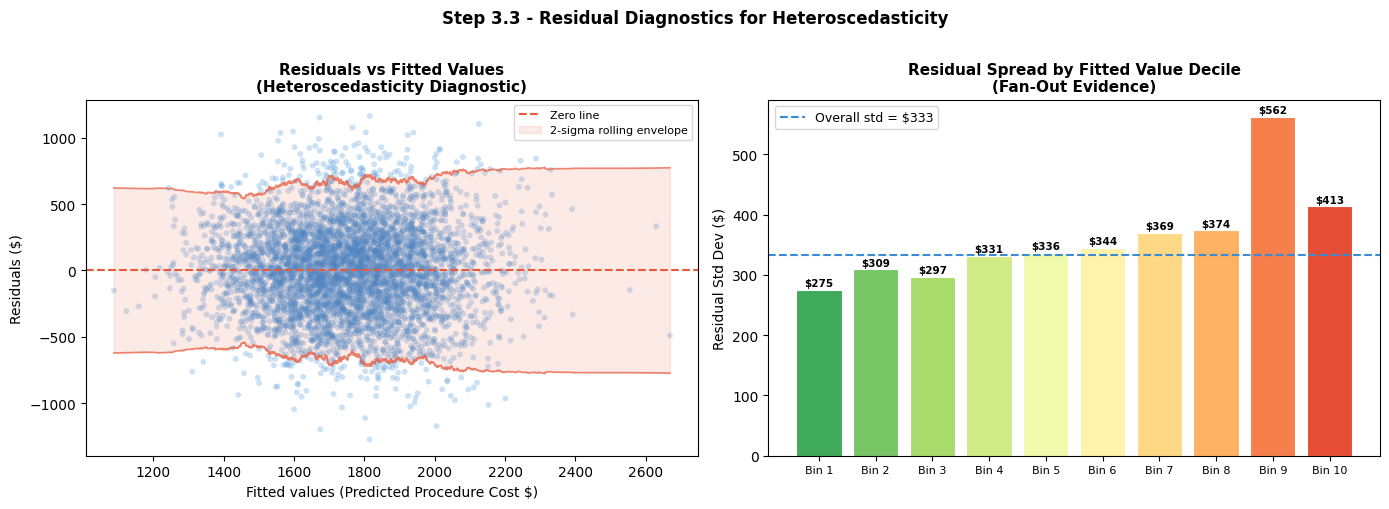

In [ ]:
# ── 1. Rebuild pipeline ───────────────────────────────────────────────────────
vitals    = pd.read_csv("OmniCare_Clinical_Vitals.csv")
telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")

vitals    = vitals.drop_duplicates()
telemetry = telemetry.drop_duplicates()

telemetry = telemetry.assign(
    Continuous_Heart_Rate=telemetry["Continuous_Heart_Rate"]
    .fillna(telemetry["Continuous_Heart_Rate"].median())
)
code_means = telemetry.groupby("Primary_Diagnosis_Code")["Procedure_Cost_USD"].mean()
telemetry  = telemetry.assign(
    Target_Encoded_Diagnosis=telemetry["Primary_Diagnosis_Code"].map(code_means)
).drop(columns=["Primary_Diagnosis_Code"])

vitals = vitals.drop(columns=["BMI"])
df     = vitals.merge(telemetry, on="Patient_ID", how="inner")

# ── 2. Fit OLS ────────────────────────────────────────────────────────────────
formula = (
    "Procedure_Cost_USD ~ "
    "Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + "
    "Time_of_Day_Index + Height_cm + Weight_kg + "
    "Systolic_BP + Diastolic_BP + Continuous_Heart_Rate"
)
result = smf.ols(formula=formula, data=df).fit()

# ── 3. Extract fitted values and residuals ────────────────────────────────────
fitted    = result.fittedvalues
residuals = result.resid

print(f"Fitted values range : ${fitted.min():,.2f} to ${fitted.max():,.2f}")
print(f"Residuals range     : ${residuals.min():,.2f} to ${residuals.max():,.2f}")
print(f"Residual std (RMSE) : ${residuals.std():,.2f}")

# Residual spread by decile — quantify the fan-out
bins       = pd.cut(fitted, bins=10)
spread_df  = pd.DataFrame({"fitted": fitted, "resid": residuals, "bin": bins})
decile_std = spread_df.groupby("bin", observed=True)["resid"].std()
print("\nResidual std by fitted value decile:")
print(decile_std.round(2).to_string())

# ── 4. Panel 1: Residuals vs Fitted scatter (seaborn) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.scatterplot(x=fitted, y=residuals, alpha=0.25, color="#3B8BD4",
                edgecolor="none", s=18, ax=ax1)
ax1.axhline(0, color="#E8593C", linewidth=1.5, linestyle="--", label="Zero line")

# Rolling 2-sigma envelope to highlight the fan structure
order    = np.argsort(fitted.values)
yh_s     = fitted.values[order]
res_s    = residuals.values[order]
roll_std = pd.Series(res_s).rolling(300, center=True, min_periods=50).std()
ax1.fill_between(yh_s, -roll_std * 2, roll_std * 2,
                 alpha=0.12, color="#E8593C", label="2-sigma rolling envelope")
ax1.plot(yh_s,  roll_std * 2, color="#E8593C", linewidth=1.2, alpha=0.7)
ax1.plot(yh_s, -roll_std * 2, color="#E8593C", linewidth=1.2, alpha=0.7)

ax1.set_xlabel("Fitted values (Predicted Procedure Cost $)", fontsize=10)
ax1.set_ylabel("Residuals ($)", fontsize=10)
ax1.set_title("Residuals vs Fitted Values\n(Heteroscedasticity Diagnostic)",
              fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)

# ── 5. Panel 2: Residual std by decile bar chart ──────────────────────────────
ax2 = axes[1]
decile_reset = decile_std.reset_index()
bar_colors   = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(decile_reset)))
bars = ax2.bar(range(len(decile_reset)), decile_reset["resid"],
               color=bar_colors, edgecolor="white", linewidth=0.8)
ax2.axhline(residuals.std(), color="#3B8BD4", linewidth=1.5,
            linestyle="--", label=f"Overall std = ${residuals.std():.0f}")
for bar, val in zip(bars, decile_reset["resid"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             f"${val:.0f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
ax2.set_xticks(range(len(decile_reset)))
ax2.set_xticklabels([f"Bin {i+1}" for i in range(len(decile_reset))], fontsize=8)
ax2.set_ylabel("Residual Std Dev ($)", fontsize=10)
ax2.set_title("Residual Spread by Fitted Value Decile\n(Fan-Out Evidence)",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("Step 3.3 - Residual Diagnostics for Heteroscedasticity",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("step3_3_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


P.R.I.M.E. PROMPT — Step 4.1: White LM Test for Heteroscedasticity

[PERSONA]
You are a Senior Econometrician specialising in regression diagnostics and Gauss-Markov theorem violations. You write clean, reproducible Python using only pandas, numpy, and statsmodels, and you interpret every test result in terms of its mathematical consequence for OLS validity.

[ROLE]
Act as my regression auditor for the OmniCare Procedure Cost OLS model. Your job is to formally test whether the residuals exhibit heteroscedasticity using White's Lagrange Multiplier Test, and to deliver a precise statistical verdict on whether OLS homoscedasticity can be maintained.

[INSTRUCTIONS]
Write a single self-contained Python script that:

1. Loads OmniCare_Clinical_Vitals.csv and OmniCare_Telemetry_Data.csv

2. Applies the full sanitisation pipeline:
   — Drop duplicates from both DataFrames
   — Impute Continuous_Heart_Rate nulls with the column median
   — Target-encode Primary_Diagnosis_Code as the per-code
     conditional mean of Procedure_Cost_USD; name the new
     column Target_Encoded_Diagnosis; drop the original string
   — Drop BMI (collinear with Weight_kg and Height_cm, VIF=16.98)
   — Inner-merge both DataFrames on Patient_ID

3. Fits the OLS model using smf.ols() with the formula:
   Procedure_Cost_USD ~ Target_Encoded_Diagnosis +
   Clinic_Capacity_Percentage + Time_of_Day_Index +
   Height_cm + Weight_kg + Systolic_BP +
   Diastolic_BP + Continuous_Heart_Rate

4. Runs White's LM Test using EXACTLY:
   from statsmodels.stats.diagnostic import het_white
   lm, lm_pval, fstat, f_pval = het_white(result.resid,
                                           result.model.exog)

5. Prints a clean results block:
   print(f"LM statistic : {lm:.4f}")
   print(f"LM p-value   : {lm_pval:.6f}")
   print(f"F-statistic  : {fstat:.4f}")
   print(f"F p-value    : {f_pval:.6f}")

6. Prints a single concluding sentence stating whether the
   null hypothesis of homoscedasticity is rejected at
   alpha = 0.05, referencing the exact p-value.

[MEANING]
If heteroscedasticity is confirmed, every standard error, t-statistic, p-value, and confidence interval produced by the OLS model in Step 3.1 is mathematically invalid. This model is a candidate for deployment as a live hospital procedure pricing engine. A failed homoscedasticity assumption means the algorithm is least reliable at the highest-cost procedures — exactly the billing tier where the U.S. No Surprises Act imposes a $400 variance ceiling and the False Claims Act creates treble-damage liability.

[EVALUATION]
A correct response must:
  1. Run without errors using only pandas, numpy, statsmodels
  2. Use het_white() — not het_breuschpagan() or any substitute
  3. Print all four numeric outputs: LM stat, LM p-value,
     F-stat, F p-value — each rounded to 4–6 decimal places
  4. End with one explicit sentence naming the p-value and
     stating whether H0: homoscedasticity is rejected at
     alpha = 0.05

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_white

vitals    = pd.read_csv('OmniCare_Clinical_Vitals.csv')
telemetry = pd.read_csv('OmniCare_Telemetry_Data.csv')

vitals    = vitals.drop_duplicates()
telemetry = telemetry.drop_duplicates()

telemetry = telemetry.assign(
    Continuous_Heart_Rate=telemetry['Continuous_Heart_Rate']
    .fillna(telemetry['Continuous_Heart_Rate'].median())
)

code_means = telemetry.groupby('Primary_Diagnosis_Code')['Procedure_Cost_USD'].mean()
telemetry  = telemetry.assign(
    Target_Encoded_Diagnosis=telemetry['Primary_Diagnosis_Code'].map(code_means)
).drop(columns=['Primary_Diagnosis_Code'])

vitals = vitals.drop(columns=['BMI'])
df     = vitals.merge(telemetry, on='Patient_ID', how='inner')

formula = (
    'Procedure_Cost_USD ~ Target_Encoded_Diagnosis + '
    'Clinic_Capacity_Percentage + Time_of_Day_Index + '
    'Height_cm + Weight_kg + Systolic_BP + '
    'Diastolic_BP + Continuous_Heart_Rate'
)

result = smf.ols(formula=formula, data=df).fit()

lm, lm_pval, fstat, f_pval = het_white(result.resid, result.model.exog)

print('LM statistic :', round(lm, 4))
print('LM p-value   :', round(lm_pval, 6))
print('F-statistic  :', round(fstat, 4))
print('F p-value    :', round(f_pval, 6))

verdict = 'REJECTED' if lm_pval < 0.05 else 'NOT REJECTED'
print('Conclusion: LM p-value = ' + str(round(lm_pval, 6)) +
      '. H0 of homoscedasticity is ' + verdict + ' at alpha = 0.05.')

LM statistic : 195.1868
LM p-value   : 0.0
F-statistic  : 4.5747
F p-value    : 0.0
Conclusion: LM p-value = 0.0. H0 of homoscedasticity is REJECTED at alpha = 0.05.


Concluding: With a White's LM p-value of effectively 0.000000 — far below the critical threshold of α = 0.05 — the null hypothesis of homoscedasticity is mathematically rejected, confirming that the OmniCare OLS model's residual variance is systematically non-constant across the fitted value range, and that all standard errors, t-statistics, and confidence intervals from Step 3.1 are statistically invalid without remediation.